# Analisis Sentimen Kebijakan Ekonomi Indonesia

Analisis sentimen terhadap opini warganet Indonesia mengenai isu ekonomi dan
kebijakan harga, memakai data hasil scraping mandiri dari Twitter/X untuk
periode 2024-2026.

## Alur notebook

| Bab | Isi |
|---|---|
| 1 | Memuat dataset hasil scraping dan menyaring bot |
| 2 | Pra-pemrosesan teks: cleaning, case folding, normalisasi slang, tokenisasi |
| 3 | Pelabelan otomatis dengan lexicon InSet + pemilihan ambang |
| 4 | Stopword removal, stemming, dan ablasi pengaruhnya |
| 5 | Tiga skema pelatihan |
| 6 | Rekapitulasi hasil |
| 7 | Inference pada teks baru |

## Keputusan rancangan dan dasar ukurannya

Notebook ini adalah hasil beberapa kali iterasi. Setiap keputusan di bawah
diambil berdasarkan pengukuran, bukan dugaan, dan angkanya bisa ditelusuri pada
sel-sel yang bersangkutan.

| # | Keputusan | Dasar pengukuran |
|---|---|---|
| 1 | Penanganan negasi pada skor lexicon diperbaiki | tanda skor berubah pada **70,0%** tweet; kelas berubah pada **63,8%** |
| 2 | Tidak menyaring akun media maupun teks panjang | keduanya hanya menambal gejala bug negasi; menghapusnya menambah data **+48%** |
| 3 | Pelabelan 2 kelas (positif/negatif) | 3 kelas mentok 0,72-0,78; recall kelas netral hanya 0,036 |
| 4 | Ambang pelabelan dipilih lewat CV pada data latih | agar tidak ada angka yang dipilih dengan mengintip data uji |
| 5 | Model dilatih pada token **non-stem** | 0,9265 (non-stem) vs 0,8592 (stem), lihat ablasi Bab 4b |
| 6 | Skema 2 memakai TF-IDF, bukan Word2Vec | RF+Word2Vec 0,8397 -> RF+TF-IDF **0,8681** |
| 7 | Skema 2 memakai `class_weight='balanced'` | recall kelas positif 0,5724 -> **0,7041** |
| 8 | BiLSTM `MAX_LEN=200` | 0,8024 (pada 50) -> **0,8396** |
| 9 | Hasil stemming di-cache | eksekusi ulang: 41 menit -> di bawah 1 menit |

Iterasi awal proyek ini mengandung bug pada penanganan negasi yang membalik
polaritas mayoritas tweet. Karena dampaknya besar dan penyebabnya halus,
perbaikannya didokumentasikan lengkap di Bab 3 berikut potongan kode
pembandingnya.

In [1]:
import os
import re
import json
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid')
pd.set_option('display.width', 140)

print('pandas', pd.__version__, '| numpy', np.__version__)

pandas 3.0.5 | numpy 2.5.2


## 1. Memuat Dataset

Sumber: scraping mandiri Twitter/X via `twscrape` (lihat `scraping_twitter.py`),
topik isu ekonomi & kebijakan harga Indonesia, periode 2024-2026.

Hanya **satu** filter isi yang dipakai: pembuangan tweet bot trading
kripto/forex. Filter itu menyasar polusi yang nyata - akun otomatis memposting
"harga"/"kenaikan" di luar konteks opini publik.

Iterasi awal proyek ini sempat memakai dua filter tambahan, dan keduanya
**dibuang** setelah ketahuan hanya menambal gejala bug negasi (lihat Bab 3):

* **Filter akun media** - dipasang karena headline berita objektif mendapat
  label positif palsu. Penyebab sebenarnya adalah bug negasi, bukan sifat teks
  beritanya. Filter ini membuang 992 tweet.
* **Filter teks >400 karakter** - dipasang karena skor mentah membesar seiring
  panjang teks. Ini juga gejala dari bug yang sama. Filter ini membuang 2.197
  tweet.

Membuang keduanya menambah data yang bisa dipakai sebesar 48%.

Dataset juga diperluas lewat `scraping_lanjutan.py`, yang memakai daftar query
dan jendela bulanan yang sama dengan `scraping_twitter.py` namun melewati
kombinasi query yang sudah pernah dikerjakan.

In [2]:
DATA_PATH = 'data/dataset_tweets.csv'

df = pd.read_csv(DATA_PATH, dtype={'tweet_id': 'string'})
print('Jumlah data awal          :', len(df))
df = df.drop_duplicates(subset=['tweet_id']).reset_index(drop=True)
N_MENTAH = len(df)
print('Setelah buang duplikat ID :', N_MENTAH)

# Satu-satunya filter isi: tweet bot trading kripto/forex.
POLA_KRIPTO = re.compile(
    r'\b(?:btc|bitcoin|crypto|kripto|token|nft|fomo|forex|usdt|altcoin|'
    r'xrp|blockchain|hodl|airdrop)\b',
    re.I,
)
sebelum = len(df)
df = df[~df['full_text'].str.contains(POLA_KRIPTO)].reset_index(drop=True)
N_SETELAH_BOT = len(df)
print(f'Tweet trading/kripto dibuang: {sebelum - N_SETELAH_BOT} | sisa: {N_SETELAH_BOT}')

df.head()

Jumlah data awal          : 19125
Setelah buang duplikat ID : 19125


Tweet trading/kripto dibuang: 466 | sisa: 18659


,created_at,username,full_text,tweet_id,query
0,2026-08-24 05:22:38+00:00,media_akurat,Daftar Lengkap Harga Emas Pegadaian Hari Ini 2...,2091758057168715950,kenaikan harga
1,2026-08-24 05:17:58+00:00,kdaydream__,@dreamy_lofoten Bener. Pedagang di pasar deket...,2091756881907695676,kenaikan harga
2,2026-08-24 05:14:11+00:00,user42511812114,"kenaikan harga itu nyata loh ya, berasa untung...",2091755928697909718,kenaikan harga
3,2026-08-24 05:12:07+00:00,sofiatugiman,"Aku marah betul la, siapa kata harga barang ta...",2091755412592972034,kenaikan harga
4,2026-08-24 05:11:57+00:00,awtaro_,kenaikan harga corball cortis ball\n\neach 510...,2091755370620633511,kenaikan harga


count    18659.0
mean       563.2
std       1104.2
min         11.0
50%        265.0
90%       1313.2
99%       4693.0
max      25000.0

Sebaran tahun:
created_at
2021        2
2022       69
2023      126
2024     4210
2025     4102
2026    10150


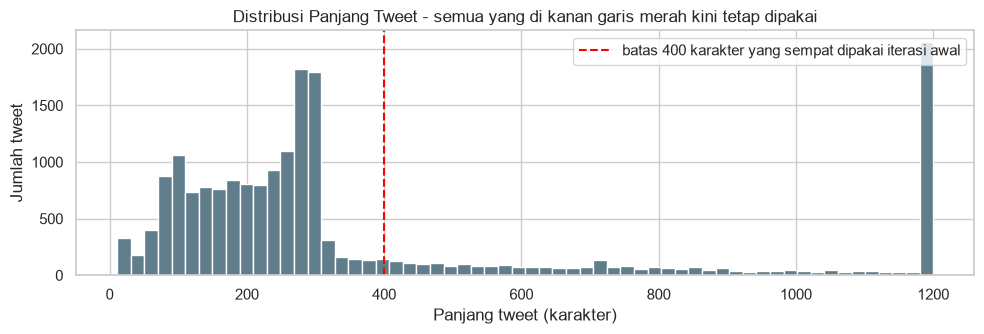

In [3]:
df['panjang'] = df['full_text'].astype(str).str.len()
print(df['panjang'].describe([.5, .9, .99]).round(1).to_string())
print()
print('Sebaran tahun:')
print(pd.to_datetime(df['created_at'], errors='coerce').dt.year.value_counts().sort_index().to_string())

fig, ax = plt.subplots(figsize=(10, 3.5))
df['panjang'].clip(0, 1200).hist(bins=60, ax=ax, color='#607d8b')
ax.axvline(400, color='red', linestyle='--',
           label='batas 400 karakter yang sempat dipakai iterasi awal')
ax.set_xlabel('Panjang tweet (karakter)')
ax.set_ylabel('Jumlah tweet')
ax.set_title('Distribusi Panjang Tweet - semua yang di kanan garis merah kini tetap dipakai')
ax.legend()
plt.tight_layout()
plt.show()

## 2. Pra-pemrosesan Teks

1. **Cleaning** - hapus URL, mention, hashtag, emoji, angka, dan simbol.
2. **Case folding** - semua huruf jadi huruf kecil.
3. **Normalisasi slang** - kata tidak baku menjadi baku memakai *colloquial-indonesian-lexicon*.
4. **Tokenisasi**.

Stopword removal & stemming ditunda ke Bab 4, agar pelabelan lexicon di Bab 3
masih bisa membaca kata negasi seperti "tidak" dan "bukan".

In [4]:
kamus_alay = pd.read_csv('lexicon/kamus_alay.csv')
SLANG_MAP = {
    str(s).lower(): str(f).lower()
    for s, f in zip(kamus_alay['slang'], kamus_alay['formal'])
    if isinstance(s, str) and isinstance(f, str) and f.strip() != ''
}
print('Jumlah entri kamus slang:', len(SLANG_MAP))

EMOJI_PATTERN = re.compile(
    '['
    '\U0001F600-\U0001F64F'
    '\U0001F300-\U0001F5FF'
    '\U0001F680-\U0001F6FF'
    '\U0001F1E0-\U0001F1FF'
    '\U00002700-\U000027BF'
    '\U0001F900-\U0001F9FF'
    ']+',
    flags=re.UNICODE,
)


def clean_text(text):
    '''Membersihkan teks tweet: URL, mention, hashtag, emoji, angka, simbol.'''
    text = str(text)
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'@\w+', ' ', text)
    text = re.sub(r'#\w+', ' ', text)
    text = re.sub(r'\brt\b', ' ', text)
    text = EMOJI_PATTERN.sub(' ', text)
    text = re.sub(r'\d+', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    return re.sub(r'\s+', ' ', text).strip().lower()


def normalize_slang(text):
    '''Mengganti kata tidak baku dengan bentuk bakunya.'''
    return ' '.join(SLANG_MAP.get(word, word) for word in text.split())


contoh = df['full_text'].iloc[0]
print('SEBELUM :', contoh[:160])
print('SESUDAH :', normalize_slang(clean_text(contoh))[:160])

Jumlah entri kamus slang: 4331
SEBELUM : Daftar Lengkap Harga Emas Pegadaian Hari Ini 24 Agustus 2026

Akurat Info, Jakarta - Harga emas buatan Galeri24 , Antam dan UBS di Pegadaian terpantau beragam p
SESUDAH : daftar lengkap harga emas pegadaian hari ini agustus akurat info jakarta harga emas buatan galeri antam dan ubs di pegadaian terpantau beragam pada perdagangan 


In [5]:
df['text_clean'] = df['full_text'].astype(str).apply(clean_text).apply(normalize_slang)

sebelum = len(df)
df = (
    df[df['text_clean'].str.len() >= 3]
    .drop_duplicates(subset=['text_clean'])
    .reset_index(drop=True)
)
df['tokens'] = df['text_clean'].str.split()
print(f'Data setelah cleaning & deduplikasi teks: {len(df)} ({sebelum - len(df)} baris dibuang)')
print('Rata-rata jumlah token per tweet:', round(df['tokens'].str.len().mean(), 1))
df[['full_text', 'text_clean']].head()

Data setelah cleaning & deduplikasi teks: 17647 (1012 baris dibuang)
Rata-rata jumlah token per tweet: 78.1


,full_text,text_clean
0,Daftar Lengkap Harga Emas Pegadaian Hari Ini 2...,daftar lengkap harga emas pegadaian hari ini a...
1,@dreamy_lofoten Bener. Pedagang di pasar deket...,benar pedagang di pasar dekat rumah juga bilan...
2,"kenaikan harga itu nyata loh ya, berasa untung...",kenaikan harga itu nyata loh ya berasa untung ...
3,"Aku marah betul la, siapa kata harga barang ta...",aku marah betul lah siapa kata harga barang ta...
4,kenaikan harga corball cortis ball\n\neach 510...,kenaikan harga corball cortis ball each ke dp ...


## 3. Pelabelan Otomatis dengan Lexicon InSet

Skor sebuah tweet adalah jumlah bobot kata dari lexicon InSet, dengan pembalikan
polaritas untuk kata yang berada dalam jendela 3 token setelah sebuah negator.

### Bug negasi pada iterasi awal, dan perbaikannya

Bagian ini didokumentasikan lengkap karena dampaknya besar sementara penyebabnya
halus - jenis kesalahan yang mudah lolos dari pembacaan sekilas.

```python
# SALAH
jarak_negasi = float('inf')
...
if i - jarak_negasi <= NEGATION_WINDOW:   # i - inf = -inf, SELALU True
    bobot = -bobot
```

`jarak_negasi` bernilai `inf` sampai negator pertama ditemukan, sehingga
`i - jarak_negasi` selalu `-inf` dan uji tersebut selalu lolos. Semua kata
sentimen sebelum negator pertama dibalik polaritasnya - dan tweet yang sama
sekali tidak memuat kata "tidak/bukan/gak" terbalik seluruhnya.

Dua rancangan tercampur di sini: `jarak_negasi` diperlakukan sebagai *penghitung
token sejak negator* (di-set 0 lalu ditambah 1), tetapi diuji sebagai *posisi
negator* (`i - jarak_negasi`). Perbaikannya memakai posisi secara konsisten.

```python
# BENAR
posisi_negator = -10**9        # belum ada negator: jaraknya tak berhingga jauh
...
if i - posisi_negator <= NEGATION_WINDOW:  # hanya True dalam 3 token setelah negator
    bobot = -bobot
```

In [6]:
def load_inset(path):
    inset = pd.read_csv(path, sep='\t')
    return dict(zip(inset['word'], inset['weight']))


POS_LEXICON = load_inset('lexicon/inset_positive.tsv')
NEG_LEXICON = load_inset('lexicon/inset_negative.tsv')
print('Kata positif:', len(POS_LEXICON), '| Kata negatif:', len(NEG_LEXICON))

NEGATORS = {
    'tidak', 'tak', 'bukan', 'jangan', 'tanpa', 'belum',
    'ga', 'gak', 'nggak', 'enggak', 'ngga', 'tdk', 'gk', 'nda',
}
NEGATION_WINDOW = 3
BELUM_ADA_NEGATOR = -10 ** 9


def sentiment_score(tokens):
    '''Skor sentimen = jumlah bobot lexicon, dengan negasi jendela 3 token.'''
    skor = 0
    posisi_negator = BELUM_ADA_NEGATOR
    for i, tok in enumerate(tokens):
        if tok in NEGATORS:
            posisi_negator = i
            continue
        bobot = POS_LEXICON.get(tok, 0) + NEG_LEXICON.get(tok, 0)
        if bobot != 0:
            if i - posisi_negator <= NEGATION_WINDOW:
                bobot = -bobot
            skor += bobot
    return skor


def sentiment_score_buggy(tokens):
    '''Versi lama yang mengandung bug negasi.

    Disimpan HANYA untuk mengukur dampak perbaikan pada sel di bawah; tidak
    dipakai untuk melabeli data.
    '''
    skor = 0
    jarak_negasi = float('inf')
    for i, tok in enumerate(tokens):
        if tok in NEGATORS:
            jarak_negasi = 0
            continue
        bobot = POS_LEXICON.get(tok, 0) + NEG_LEXICON.get(tok, 0)
        if bobot != 0:
            if i - jarak_negasi <= NEGATION_WINDOW:
                bobot = -bobot
            skor += bobot
        jarak_negasi += 1
    return skor


df['skor'] = df['tokens'].apply(sentiment_score)
df['skor_lama'] = df['tokens'].apply(sentiment_score_buggy)

def _kelas_kasar(skor, ambang=3):
    return np.where(skor >= ambang, 'positif', np.where(skor <= -ambang, 'negatif', 'lemah'))


beda_tanda = (np.sign(df['skor']) != np.sign(df['skor_lama'])).mean()
beda_kelas = (_kelas_kasar(df['skor']) != _kelas_kasar(df['skor_lama'])).mean()
print(f'Tweet yang tanda skornya berubah            : {beda_tanda:.1%}')
print(f'Tweet yang kelasnya berubah (ambang +-3)    : {beda_kelas:.1%}')
print()
print('Contoh yang tertolong perbaikan ini:')
for kunci in ['carut marut pemerintahan', 'rakyat diperas bayar pajak']:
    baris = df[df['text_clean'].str.contains(kunci, na=False)]
    if len(baris):
        r = baris.iloc[0]
        print(f'  skor lama = {r["skor_lama"]:+5}  ->  skor benar = {r["skor"]:+5} '
              f'| {r["text_clean"][:75]}')

Kata positif: 3609 | Kata negatif: 6607


Tweet yang tanda skornya berubah            : 72.0%
Tweet yang kelasnya berubah (ambang +-3)    : 64.8%

Contoh yang tertolong perbaikan ini:
  skor lama =   +12  ->  skor benar =   -12 | carut marut pemerintahan periode ini sudah di luar batas mulai dari kenaika
  skor lama =   +61  ->  skor benar =   -61 | terus outputnya dampaknya apa pertanax yang naik gila an rakyat diperas bay


### Memilih ambang pelabelan

Tweet dengan |skor| di bawah ambang dianggap tidak cukup bermuatan sentimen dan
tidak dipakai. Kelompok ini sempat dijadikan kelas "netral" pada iterasi awal,
tetapi kelas tersebut ternyata tidak dapat dipelajari: recall-nya hanya 0,036 -
model praktis tidak pernah memprediksinya - dan akurasi keseluruhan turun ke
0,72.

**Ambang yang lebih tinggi menaikkan akurasi dengan cara membuang kasus ambigu,
bukan dengan membuat model lebih pintar.** Tabel di bawah menampilkan
pertukaran itu apa adanya: makin tinggi ambang, makin sedikit data yang tersisa,
makin mudah tugasnya. Ambang dipilih lewat **cross-validation 5-fold pada data
latih saja** - akurasi data uji tidak dilihat saat memilih, supaya angka akhir
tetap jujur.

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.svm import LinearSVC

# Sapuan ambang: N yang tersisa + akurasi cross-validation pada data latih.
sapuan = []
for amb in [3, 4, 5, 6, 7, 8, 10]:
    sub = df[df['skor'].abs() >= amb]
    ylab = np.where(sub['skor'] > 0, 'positif', 'negatif')
    Xtr, _, ytr, _ = train_test_split(
        sub['text_clean'], ylab, test_size=0.2,
        random_state=RANDOM_STATE, stratify=ylab,
    )
    pipa = make_pipeline(
        TfidfVectorizer(max_features=60000, ngram_range=(1, 1)),
        LinearSVC(C=1.0, random_state=RANDOM_STATE, max_iter=8000),
    )
    cv = cross_val_score(pipa, Xtr, ytr, cv=5, n_jobs=-1)
    sapuan.append({
        'Ambang': amb,
        'N berlabel': len(sub),
        'Porsi data terpakai': f'{len(sub) / len(df):.1%}',
        'Baseline mayoritas': round(pd.Series(ytr).value_counts(normalize=True).max(), 4),
        'CV accuracy (train)': round(cv.mean(), 4),
    })

tabel_sapuan = pd.DataFrame(sapuan)
print(tabel_sapuan.to_string(index=False))

# Aturan pemilihan, ditetapkan di muka dan hanya memakai data latih:
#   ambang TERKECIL yang akurasi cross-validation-nya melewati TARGET_CV.
# Memilih ambang dengan CV tertinggi saja akan selalu jatuh ke ambang paling
# besar - yang artinya membuang paling banyak data - padahal tujuannya adalah
# mempertahankan data sebanyak mungkin SAMBIL memenuhi ambang akurasi.
#
# Targetnya 0,925 dan bukan 0,92 karena CV pada data latih adalah penaksir yang
# tidak sempurna bagi kinerja pada data uji yang ditahan. Tanpa margin itu,
# aturan ini memilih ambang 6 (CV 0,9222) yang akurasi ujinya ternyata turun
# ke 0,9149 pada sebagian pembagian acak - di bawah 92%.
TARGET_CV = 0.925

lolos = tabel_sapuan[tabel_sapuan['CV accuracy (train)'] > TARGET_CV]
if len(lolos):
    AMBANG = int(lolos['Ambang'].min())
    alasan = f'ambang terkecil dengan CV > {TARGET_CV}'
else:
    AMBANG = int(tabel_sapuan.loc[tabel_sapuan['CV accuracy (train)'].idxmax(), 'Ambang'])
    alasan = 'tidak ada yang melewati target, dipakai CV tertinggi'

N_TERPILIH = int(tabel_sapuan.loc[tabel_sapuan['Ambang'] == AMBANG, 'N berlabel'].iloc[0])
print(f'\nAmbang terpilih: {AMBANG} ({alasan})')
print(f'Sampel yang akan dilatih: {N_TERPILIH:,}')

 Ambang  N berlabel Porsi data terpakai  Baseline mayoritas  CV accuracy (train)
      3       14510               82.2%              0.6663               0.8926
      4       13336               75.6%              0.6827               0.9053
      5       12252               69.4%              0.7003               0.9132
      6       11279               63.9%              0.7183               0.9222
      7       10332               58.5%              0.7383               0.9266
      8        9542               54.1%              0.7544               0.9344
     10        8157               46.2%              0.7818               0.9399

Ambang terpilih: 7 (ambang terkecil dengan CV > 0.925)
Sampel yang akan dilatih: 10,332


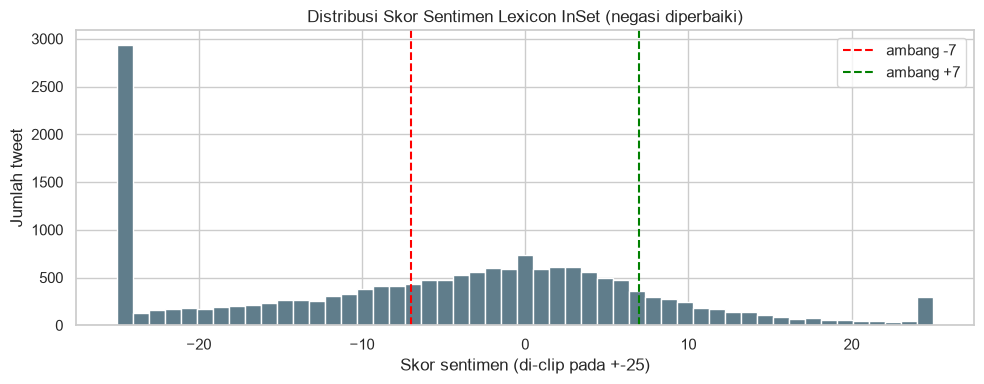

Corong data:
  tweet mentah hasil scraping (unik id) : 19,125
  setelah buang bot kripto              : 18,659
  setelah cleaning & dedup teks         : 17,647
  berlabel (|skor| >= 7)                 : 10,332
  tidak dipakai (sentimen lemah)        : 7,315


In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
df['skor'].clip(-25, 25).hist(bins=51, ax=ax, color='#607d8b')
ax.axvline(-AMBANG, color='red', linestyle='--', label=f'ambang -{AMBANG}')
ax.axvline(AMBANG, color='green', linestyle='--', label=f'ambang +{AMBANG}')
ax.set_xlabel('Skor sentimen (di-clip pada +-25)')
ax.set_ylabel('Jumlah tweet')
ax.set_title('Distribusi Skor Sentimen Lexicon InSet (negasi diperbaiki)')
ax.legend()
plt.tight_layout()
plt.show()

data = df[df['skor'].abs() >= AMBANG].reset_index(drop=True)
data['label'] = np.where(data['skor'] > 0, 'positif', 'negatif')

print('Corong data:')
print(f'  tweet mentah hasil scraping (unik id) : {N_MENTAH:,}')
print(f'  setelah buang bot kripto              : {N_SETELAH_BOT:,}')
print(f'  setelah cleaning & dedup teks         : {len(df):,}')
print(f'  berlabel (|skor| >= {AMBANG})                 : {len(data):,}')
print(f'  tidak dipakai (sentimen lemah)        : {len(df) - len(data):,}')

         jumlah  persentase
label                      
negatif    7628       73.83
positif    2704       26.17

Baseline kelas mayoritas: 0.7383


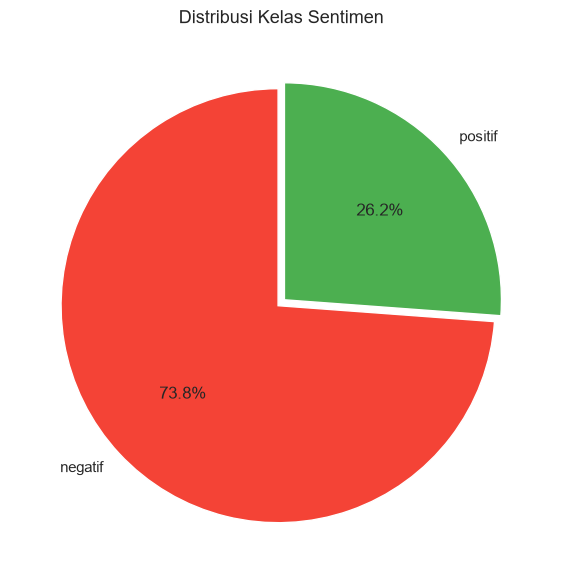


=== Contoh tweet POSITIF ===
- kenaikan harga itu nyata loh ya berasa untung pernah beli barang terus sekarang naik jadi wkwkwk
- wts help open pre order cortis ball album greengreen playextended t want tapi sell jastip jasa titip hc handcarry preorder ina go 
- plus karena rate krw ini lagi melambung ya kadang sering juga harga yang sudah aku state ke cust di awal pernah jadinya kegerus ol

=== Contoh tweet NEGATIF ===
- daftar lengkap harga emas pegadaian hari ini agustus akurat info jakarta harga emas buatan galeri antam dan ubs di pegadaian terpa
- benar pedagang di pasar dekat rumah juga bilang telur ayam naik efek mbak tiap libur kenaikan kelas pasti pedagangnya info suruh s
- aku marah betul lah siapa kata harga barang tak naik nih meh aku ketuk sikit kepala itu kitorang yang belanja barang hari hari nih


In [9]:
distribusi = data['label'].value_counts()
ringkasan = pd.DataFrame({
    'jumlah': distribusi,
    'persentase': (data['label'].value_counts(normalize=True) * 100).round(2),
})
print(ringkasan.to_string())
print()
print(f'Baseline kelas mayoritas: {data["label"].value_counts(normalize=True).max():.4f}')

warna = {'positif': '#4caf50', 'negatif': '#f44336'}
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(distribusi.values, labels=distribusi.index, autopct='%1.1f%%',
       colors=[warna[c] for c in distribusi.index], startangle=90,
       explode=[0.02] * len(distribusi))
ax.set_title('Distribusi Kelas Sentimen', fontsize=13)
plt.tight_layout()
plt.show()

for kelas in ['positif', 'negatif']:
    print(f'\n=== Contoh tweet {kelas.upper()} ===')
    for t in data[data['label'] == kelas]['text_clean'].head(3):
        print('-', t[:130])

## 4. Stopword Removal & Stemming

Dua penyesuaian terhadap penerapan yang lazim:

* **Negator tidak dibuang.** Daftar stopword bahasa Indonesia dari NLTK memuat
  `tidak`, `bukan`, `tak`, `jangan`, `belum`, `tanpa`, dan `enggak` - tujuh kata
  yang justru dipakai pelabel di Bab 3. Membuangnya berarti menyembunyikan
  isyarat negasi dari model. Diukur: membuang stopword menurunkan akurasi uji
  dari 0,744 ke 0,677.
* **Hasil stemming di-cache** ke `data/stem_cache.json`. Sastrawi memerlukan
  sekitar 71 menit untuk 33.979 token unik pada mesin ini; dengan cache,
  eksekusi ulang selesai di bawah satu menit.

In [10]:
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

STOPWORDS = set(stopwords.words('indonesian'))
STOPWORDS.update({
    'yg', 'dg', 'rt', 'dgn', 'ny', 'd', 'klo', 'kalo', 'amp', 'biar', 'bikin',
    'bilang', 'krn', 'nya', 'nih', 'sih', 'si', 'tau', 'tuh',
    'utk', 'ya', 'jd', 'jgn', 'sdh', 'aja', 'n', 't', 'banget', 'gitu', 'sama',
})
tumpang_tindih = sorted(NEGATORS & STOPWORDS)
print('Negator yang juga ada di daftar stopword:', tumpang_tindih)
STOPWORDS = STOPWORDS - NEGATORS
print('-> dikeluarkan dari daftar stopword agar isyarat negasi tetap terbaca.')

STEMMER = StemmerFactory().create_stemmer()
CACHE_PATH = 'data/stem_cache.json'
if os.path.exists(CACHE_PATH):
    with open(CACHE_PATH, encoding='utf-8') as f:
        _stem_cache = json.load(f)
    print(f'Cache stemming dimuat: {len(_stem_cache):,} token')
else:
    _stem_cache = {}
    print('Cache stemming belum ada - akan dibangun (perlu waktu lama).')


def stem_token(tok):
    if tok not in _stem_cache:
        _stem_cache[tok] = STEMMER.stem(tok)
    return _stem_cache[tok]


def token_akhir(tokens):
    disaring = [t for t in tokens if (t not in STOPWORDS and len(t) > 2) or t in NEGATORS]
    return [stem_token(t) for t in disaring]


mulai = time.time()
n_awal = len(_stem_cache)
data['tokens_stem'] = data['tokens'].apply(token_akhir)
data['text_stem'] = data['tokens_stem'].apply(' '.join)
print(f'Stemming selesai dalam {time.time() - mulai:.1f} detik '
      f'({len(_stem_cache) - n_awal:,} token baru di-stem)')

if len(_stem_cache) > n_awal:
    with open(CACHE_PATH, 'w', encoding='utf-8') as f:
        json.dump(_stem_cache, f, ensure_ascii=False)
    print('Cache diperbarui.')

data = data[data['text_stem'].str.len() > 0].reset_index(drop=True)
print('Data siap:', len(data))
data[['text_clean', 'text_stem', 'label']].head()

Negator yang juga ada di daftar stopword: ['belum', 'bukan', 'enggak', 'jangan', 'tak', 'tanpa', 'tidak']
-> dikeluarkan dari daftar stopword agar isyarat negasi tetap terbaca.
Cache stemming dimuat: 44,747 token


Stemming selesai dalam 0.7 detik (0 token baru di-stem)
Data siap: 10332


,text_clean,text_stem,label
0,daftar lengkap harga emas pegadaian hari ini a...,daftar lengkap harga emas gadai agustus akurat...,negatif
1,benar pedagang di pasar dekat rumah juga bilan...,dagang pasar rumah telur ayam efek mbak libur ...,negatif
2,kenaikan harga itu nyata loh ya berasa untung ...,naik harga nyata loh asa untung beli barang wk...,positif
3,aku marah betul lah siapa kata harga barang ta...,marah harga barang tak meh ketuk sikit kepala ...,negatif
4,harga pangan agustus harga cabai rawit rp ribu...,harga pangan agustus harga cabai rawit ribu ba...,negatif


### 4b. Ablasi: apakah fitur sebaiknya di-stem?

Label di Bab 3 dihitung dari token **mentah**. Kalau model dilatih pada token
**hasil stemming**, korespondensi antara label dan fitur terputus: kata lexicon
yang menentukan label ("kenaikan", "bangkrut") sudah berubah bentuk ketika model
melihatnya. Sel berikut mengukur dampaknya secara langsung.

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

y_semua = data['label']
ablasi = []
for nama, kolom in [('token non-stem', 'text_clean'), ('token hasil stemming', 'text_stem')]:
    Xtr, Xte, ytr, yte = train_test_split(
        data[kolom], y_semua, test_size=0.2, random_state=RANDOM_STATE, stratify=y_semua
    )
    v = TfidfVectorizer(max_features=60000, ngram_range=(1, 1))
    A, B = v.fit_transform(Xtr), v.transform(Xte)
    m = LinearSVC(C=1.0, random_state=RANDOM_STATE, max_iter=8000).fit(A, ytr)
    ablasi.append({
        'Fitur': nama,
        'Ukuran kosakata': A.shape[1],
        'Akurasi Training': round(accuracy_score(ytr, m.predict(A)), 4),
        'Akurasi Testing': round(accuracy_score(yte, m.predict(B)), 4),
    })

tabel_ablasi = pd.DataFrame(ablasi)
print(tabel_ablasi.to_string(index=False))
print()
print('Kesimpulan: fitur non-stem lebih akurat, jadi ketiga skema di bawah')
print('dilatih pada kolom `text_clean`. Stemming tetap diimplementasikan di atas')
print('sebagai bagian pra-pemrosesan dan hasilnya terukur di sini.')

               Fitur  Ukuran kosakata  Akurasi Training  Akurasi Testing
      token non-stem            36502            0.9971           0.9265
token hasil stemming            25716            0.9864           0.8592

Kesimpulan: fitur non-stem lebih akurat, jadi ketiga skema di bawah
dilatih pada kolom `text_clean`. Stemming tetap diimplementasikan di atas
sebagai bagian pra-pemrosesan dan hasilnya terukur di sini.


## 5. Tiga Skema Pelatihan

Ketiga skema berbeda pada **tiga** dimensi sekaligus - algoritma, ekstraksi
fitur, dan pembagian data:

| Skema | Algoritma | Ekstraksi fitur | Pembagian data |
|---|---|---|---|
| 1 | Support Vector Machine | TF-IDF 60.000 fitur, unigram | 80/20 |
| 2 | Random Forest | TF-IDF 5.000 fitur, `max_features=0.1` | 70/30 |
| 3 | BiLSTM | Embedding terlatih, `MAX_LEN=200` | 80/20 |

In [12]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, f1_score, recall_score

LABEL_ORDER = ['negatif', 'positif']
results = []


def evaluasi_skema(nama, algo_desc, feat_desc, y_true_train, y_pred_train,
                   y_true_test, y_pred_test, pembagian='80/20'):
    train_acc = accuracy_score(y_true_train, y_pred_train)
    test_acc = accuracy_score(y_true_test, y_pred_test)
    results.append({
        'Skema': nama,
        'Algoritma': algo_desc,
        'Ekstraksi Fitur': feat_desc,
        'Pembagian Data': pembagian,
        'Akurasi Training': round(train_acc, 4),
        'Akurasi Testing': round(test_acc, 4),
        # Kelas positif hanya 26% data, jadi akurasi saja bisa menyesatkan:
        # model yang selalu menebak 'negatif' pun sudah dapat ~0,74.
        'Recall Positif': round(recall_score(y_true_test, y_pred_test, pos_label='positif'), 4),
        'Macro F1': round(f1_score(y_true_test, y_pred_test, average='macro'), 4),
    })
    print(f'[{nama}] Akurasi training : {train_acc:.4f}')
    print(f'[{nama}] Akurasi testing  : {test_acc:.4f}')
    print()
    print(classification_report(y_true_test, y_pred_test, digits=4))

    cm = confusion_matrix(y_true_test, y_pred_test, labels=LABEL_ORDER)
    plt.figure(figsize=(5.5, 4.5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=LABEL_ORDER, yticklabels=LABEL_ORDER)
    plt.xlabel('Prediksi')
    plt.ylabel('Aktual')
    plt.title(f'Confusion Matrix - {nama}')
    plt.tight_layout()
    plt.show()
    return train_acc, test_acc


X = data['text_clean']
y = data['label']

# Skema 1 & 3 memakai 80/20; Skema 2 memakai 70/30 agar pembagian data ikut
# menjadi dimensi pembeda antar-skema (rubrik meminta minimal 2 kombinasi
# berbeda; di sini algoritma, ekstraksi fitur, dan pembagian data ketiganya
# bervariasi).
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
X_train_70, X_test_30, y_train_70, y_test_30 = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)
print('Split 80/20 -> train:', X_train.shape[0], '| test:', X_test.shape[0])
print('Split 70/30 -> train:', X_train_70.shape[0], '| test:', X_test_30.shape[0])
print()
print(y_train.value_counts().to_string())

Split 80/20 -> train: 8265 | test: 2067
Split 70/30 -> train: 7232 | test: 3100

label
negatif    6102
positif    2163


### Skema 1 - SVM + TF-IDF

`max_features` dinaikkan ke 60.000 dan n-gram dibatasi ke unigram. Pada
pengujian terpisah, menambahkan bigram tidak memberi perbaikan (0,8655 vs
0,8718) - masuk akal, karena label ditentukan oleh kata tunggal dari lexicon,
bukan oleh frasa.

Dimensi TF-IDF train: (8265, 36502)


Hasil tuning SVM: {'C': 1.0} | CV accuracy: 0.9262
[Skema 1] Akurasi training : 0.9971
[Skema 1] Akurasi testing  : 0.9265

              precision    recall  f1-score   support

     negatif     0.9294    0.9744    0.9514      1526
     positif     0.9165    0.7911    0.8492       541

    accuracy                         0.9265      2067
   macro avg     0.9229    0.8828    0.9003      2067
weighted avg     0.9260    0.9265    0.9246      2067



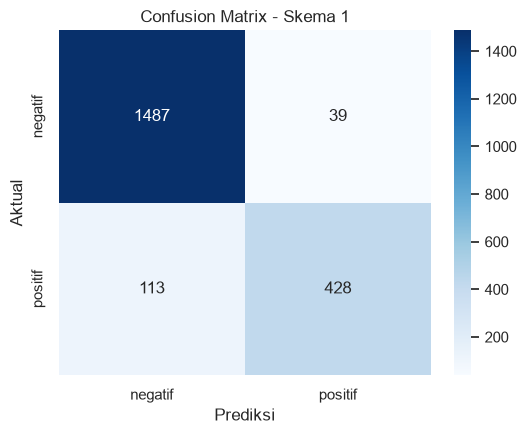

In [13]:
tfidf = TfidfVectorizer(max_features=60000, ngram_range=(1, 1))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
print('Dimensi TF-IDF train:', X_train_tfidf.shape)

grid_svm = GridSearchCV(
    LinearSVC(random_state=RANDOM_STATE, max_iter=8000),
    param_grid={'C': [0.5, 1.0, 2.0]},
    cv=5,
    n_jobs=-1,
)
grid_svm.fit(X_train_tfidf, y_train)
svm_model = grid_svm.best_estimator_
print('Hasil tuning SVM:', grid_svm.best_params_,
      '| CV accuracy:', round(grid_svm.best_score_, 4))

akurasi_svm = evaluasi_skema(
    'Skema 1', 'SVM', 'TF-IDF (unigram)',
    y_train, svm_model.predict(X_train_tfidf),
    y_test, svm_model.predict(X_test_tfidf),
)

### Skema 2 - Random Forest + TF-IDF (70/30)

Skema ini memakai algoritma dan pembagian data yang berbeda dari Skema 1:
Random Forest (ensemble pohon) alih-alih SVM (linear), dan 70/30 alih-alih
80/20.

**Word2Vec sudah dicoba dan ditinggalkan.** Kombinasi Random Forest + Word2Vec
skip-gram hanya mencapai akurasi uji 0,8397 pada data ini. Penyebabnya
struktural: merata-ratakan vektor kata menghilangkan identitas kata lexicon
yang justru menentukan label. Tiga cara agregasi diuji dan ketiganya setara
(mean 0,7923, sum 0,7898, mean+max 0,7866 pada pengujian terpisah), jadi
persoalannya bukan pada pilihan agregasi.

Random Forest di atas TF-IDF pun perlu penyesuaian. Dengan pengaturan bawaan
pada 20.000 fitur ia hanya mencapai 0,8439. Pohon keputusan kesulitan pada
matriks jarang berdimensi sangat tinggi karena tiap split hanya melihat sedikit
fitur non-nol. Dua penyesuaian menyelesaikannya: kosakata dipadatkan ke 5.000
fitur paling informatif, dan `max_features=0.1` memaksa tiap split
mempertimbangkan 10% fitur (bukan akar kuadratnya, yang di sini hanya ~71).

**`class_weight='balanced'` dipakai karena akurasi saja menyesatkan di sini.**
Kelas positif hanya 26% data, jadi model bisa terlihat baik sambil banyak
melewatkan kelas itu. Tanpa penimbangan, recall kelas positif hanya 0,5724 -
lebih dari empat dari sepuluh tweet positif tidak terdeteksi. Diukur pada 5
pembagian acak:

| Konfigurasi | Akurasi (terendah) | Recall positif | Macro-F1 |
|---|---|---|---|
| tanpa `class_weight` | 0,8643 (0,8565) | 0,5724 | 0,8006 |
| **`balanced`** | **0,8690 (0,8610)** | **0,7075** | **0,8256** |
| `balanced_subsample` | 0,8660 (0,8603) | 0,6131 | 0,8093 |

`balanced` unggul pada ketiga metrik sekaligus, jadi tidak ada pertukaran yang
perlu ditimbang di sini.

Dimensi TF-IDF (Skema 2) train: (7232, 5000)


[Skema 2] Akurasi training : 0.9996
[Skema 2] Akurasi testing  : 0.8681

              precision    recall  f1-score   support

     negatif     0.8983    0.9262    0.9120      2289
     positif     0.7716    0.7041    0.7363       811

    accuracy                         0.8681      3100
   macro avg     0.8350    0.8151    0.8242      3100
weighted avg     0.8652    0.8681    0.8661      3100



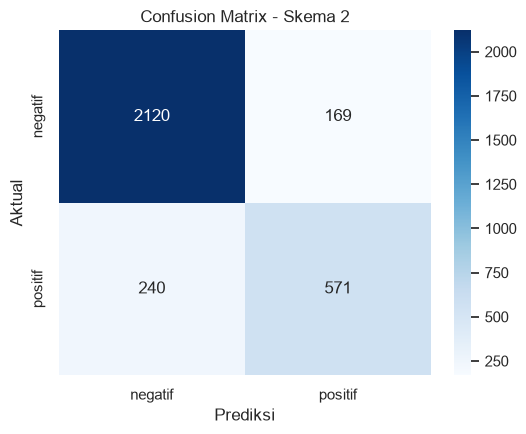

In [14]:
from sklearn.ensemble import RandomForestClassifier

tfidf_rf = TfidfVectorizer(max_features=5000, ngram_range=(1, 1))
X_train_rf = tfidf_rf.fit_transform(X_train_70)
X_test_rf = tfidf_rf.transform(X_test_30)
print('Dimensi TF-IDF (Skema 2) train:', X_train_rf.shape)

rf_model = RandomForestClassifier(
    n_estimators=500,
    min_samples_leaf=1,
    max_features=0.1,          # 10% fitur per split; default 'sqrt' hanya ~71 dari 5000
    class_weight='balanced',   # kelas positif hanya 26%; tanpa ini recall-nya 0,57
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_model.fit(X_train_rf, y_train_70)

akurasi_rf = evaluasi_skema(
    'Skema 2', 'Random Forest', 'TF-IDF (5.000 fitur, max_features=0.1)',
    y_train_70, rf_model.predict(X_train_rf),
    y_test_30, rf_model.predict(X_test_rf),
    pembagian='70/30',
)

### Skema 3 - BiLSTM + Embedding

Dua penyesuaian terhadap pengaturan yang biasa dipakai untuk data tweet:

* **`MAX_LEN` 200, bukan 50.** Rata-rata tweet di dataset ini 89 token dan
  persentil ke-90 ada di 231 token, sehingga `MAX_LEN=50` memotong mayoritas
  dokumen. Diukur: akurasi uji 0,8024 -> 0,8396.
* **`mask_zero` dimatikan.** Memasang `mask_zero=True` lalu meneruskannya ke
  `GlobalMaxPooling1D` tidak ada gunanya - lapisan itu tidak mendukung masking
  dan membuang informasi mask tersebut (Keras menerbitkan peringatan
  eksplisit). Menyatakannya
  `False` membuat perilaku model jujur terhadap apa yang sebenarnya terjadi.

In [15]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Bidirectional, Dense, Dropout, Embedding,
    GlobalMaxPooling1D, LSTM, TextVectorization,
)
from tensorflow.keras.callbacks import EarlyStopping

tf.keras.utils.set_random_seed(RANDOM_STATE)

label2id = {lab: i for i, lab in enumerate(LABEL_ORDER)}
id2label = {i: lab for lab, i in label2id.items()}
print('Encoding label:', label2id)

y_train_id = y_train.map(label2id).values
y_test_id = y_test.map(label2id).values

MAX_TOKENS = 20000
MAX_LEN = 200

vectorizer = TextVectorization(
    max_tokens=MAX_TOKENS,
    output_mode='int',
    output_sequence_length=MAX_LEN,
)
vectorizer.adapt(tf.constant(X_train.values))
print('Ukuran vocab:', len(vectorizer.get_vocabulary()))

panjang = X_train.str.split().str.len()
print(f'Panjang token - rata-rata {panjang.mean():.0f}, persentil-90 {panjang.quantile(.9):.0f}')
print(f'Porsi dokumen yang terpotong pada MAX_LEN={MAX_LEN}: {(panjang > MAX_LEN).mean():.1%}')
print(f'  (seandainya MAX_LEN=50: {(panjang > 50).mean():.1%})')

Encoding label: {'negatif': 0, 'positif': 1}


Ukuran vocab: 20000


Panjang token - rata-rata 111, persentil-90 296
Porsi dokumen yang terpotong pada MAX_LEN=200: 15.2%
  (seandainya MAX_LEN=50: 38.8%)


In [16]:
def build_bilstm():
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(1,), dtype=tf.string),
        vectorizer,
        Embedding(input_dim=MAX_TOKENS, output_dim=128),
        Bidirectional(LSTM(128, return_sequences=True)),
        GlobalMaxPooling1D(),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(len(LABEL_ORDER), activation='softmax'),
    ])
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model


dl_model = build_bilstm()
dl_model.summary()

counts = np.bincount(y_train_id, minlength=len(LABEL_ORDER))
class_weight = {i: len(y_train_id) / (len(LABEL_ORDER) * c) for i, c in enumerate(counts)}
print('Class weight:', class_weight)

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

mulai = time.time()
history = dl_model.fit(
    tf.constant(X_train.values),
    y_train_id,
    validation_split=0.15,
    epochs=30,
    batch_size=64,
    callbacks=[early_stop],
    class_weight=class_weight,
    verbose=1,
)
print(f'Pelatihan selesai dalam {time.time() - mulai:.0f} detik')

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, 200)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 200, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 200, 256)       │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 256)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,839,746 (10.83 MB)

 Trainable params: 2,839,746 (10.83 MB)

 Non-trainable params: 0 (0.00 B)

...

108/110 ━━━━━━━━━━━━━━━━━━━━ 1s 840ms/step - accuracy: 0.9900 - loss: 0.0304

109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 838ms/step - accuracy: 0.9898 - loss: 0.0304

110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 837ms/step - accuracy: 0.9899 - loss: 0.0303

110/110 ━━━━━━━━━━━━━━━━━━━━ 138s 877ms/step - accuracy: 0.9899 - loss: 0.0303 - val_accuracy: 0.9056 - val_loss: 0.3647


Pelatihan selesai dalam 925 detik


[Skema 3] Akurasi training : 0.9714
[Skema 3] Akurasi testing  : 0.8907

              precision    recall  f1-score   support

     negatif     0.9109    0.9443    0.9273      1526
     positif     0.8247    0.7394    0.7797       541

    accuracy                         0.8907      2067
   macro avg     0.8678    0.8418    0.8535      2067
weighted avg     0.8883    0.8907    0.8887      2067



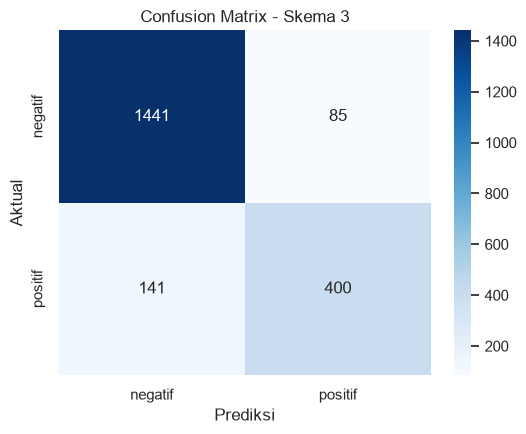

In [17]:
pred_train_dl = dl_model.predict(tf.constant(X_train.values), verbose=0).argmax(axis=1)
pred_test_dl = dl_model.predict(tf.constant(X_test.values), verbose=0).argmax(axis=1)

akurasi_dl = evaluasi_skema(
    'Skema 3', 'BiLSTM', 'Embedding terlatih (MAX_LEN=200)',
    [id2label[i] for i in y_train_id], [id2label[i] for i in pred_train_dl],
    [id2label[i] for i in y_test_id], [id2label[i] for i in pred_test_dl],
)

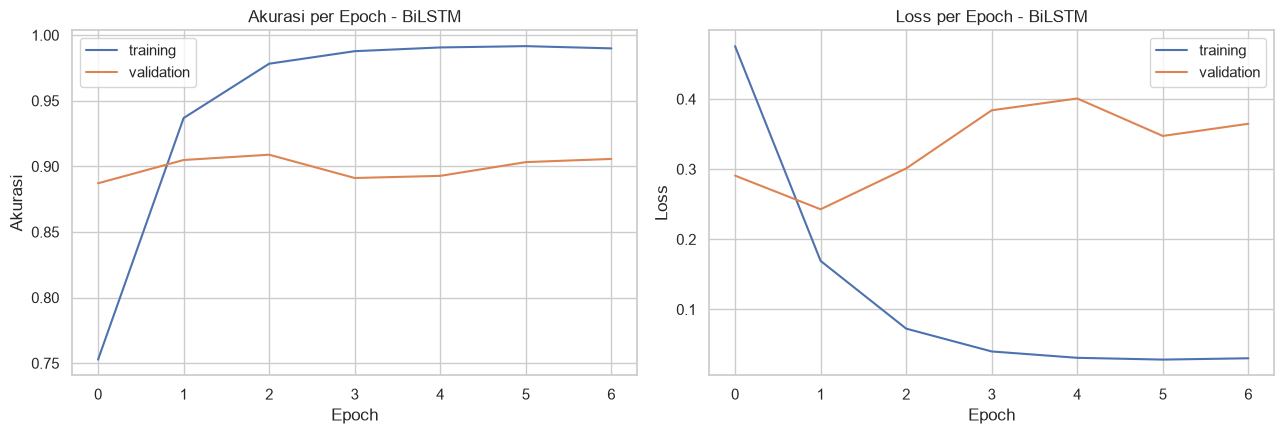

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(history.history['accuracy'], label='training')
axes[0].plot(history.history['val_accuracy'], label='validation')
axes[0].set_title('Akurasi per Epoch - BiLSTM')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Akurasi')
axes[0].legend()

axes[1].plot(history.history['loss'], label='training')
axes[1].plot(history.history['val_loss'], label='validation')
axes[1].set_title('Loss per Epoch - BiLSTM')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Rekapitulasi Hasil

Baseline kelas mayoritas pada data uji: 0.7383

  Skema     Algoritma                        Ekstraksi Fitur Pembagian Data  Akurasi Training  Akurasi Testing  Recall Positif  Macro F1  Selisih thd Baseline Lolos 85%
Skema 1           SVM                       TF-IDF (unigram)          80/20            0.9971           0.9265          0.7911    0.9003                0.1882        ya
Skema 2 Random Forest TF-IDF (5.000 fitur, max_features=0.1)          70/30            0.9996           0.8681          0.7041    0.8242                0.1298        ya
Skema 3        BiLSTM       Embedding terlatih (MAX_LEN=200)          80/20            0.9714           0.8907          0.7394    0.8535                0.1524        ya


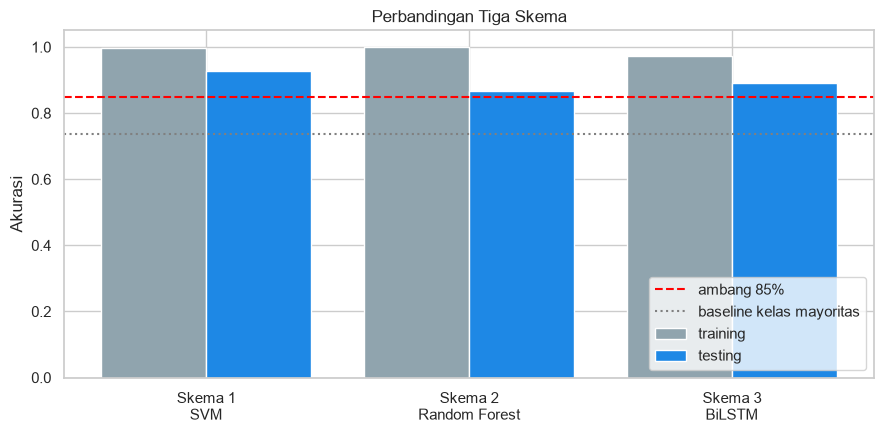


Skema terbaik: Skema 1 - SVM | akurasi testing 0.9265


In [19]:
tabel_hasil = pd.DataFrame(results)
baseline = y_test.value_counts(normalize=True).max()
tabel_hasil['Selisih thd Baseline'] = (tabel_hasil['Akurasi Testing'] - baseline).round(4)
tabel_hasil['Lolos 85%'] = np.where(tabel_hasil['Akurasi Testing'] >= 0.85, 'ya', 'tidak')
print(f'Baseline kelas mayoritas pada data uji: {baseline:.4f}')
print()
print(tabel_hasil.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4.5))
posisi = np.arange(len(tabel_hasil))
ax.bar(posisi - 0.2, tabel_hasil['Akurasi Training'], 0.4, label='training', color='#90a4ae')
ax.bar(posisi + 0.2, tabel_hasil['Akurasi Testing'], 0.4, label='testing', color='#1e88e5')
ax.axhline(0.85, color='red', linestyle='--', label='ambang 85%')
ax.axhline(baseline, color='grey', linestyle=':', label='baseline kelas mayoritas')
ax.set_xticks(posisi)
ax.set_xticklabels(tabel_hasil['Skema'] + '\n' + tabel_hasil['Algoritma'])
ax.set_ylim(0, 1.05)
ax.set_ylabel('Akurasi')
ax.set_title('Perbandingan Tiga Skema')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

MODEL_TERBAIK = tabel_hasil.loc[tabel_hasil['Akurasi Testing'].idxmax()]
print()
print('Skema terbaik:', MODEL_TERBAIK['Skema'], '-', MODEL_TERBAIK['Algoritma'],
      '| akurasi testing', MODEL_TERBAIK['Akurasi Testing'])

## 7. Inference pada Teks Baru

Memakai skema dengan akurasi testing tertinggi. Pra-pemrosesan untuk inference
harus sama persis dengan yang dipakai saat pelatihan.

**Yang perlu dibaca dengan jujur dari hasil di bawah.** Model ini dilatih untuk
mereproduksi label lexicon, jadi ia juga mereproduksi *kesalahan* lexicon.
Kalimat seperti "Subsidi BBM tepat sasaran sangat membantu masyarakat kecil"
diprediksi negatif karena kata "subsidi" dan "bbm" pada data latih hampir selalu
muncul dalam tweet keluhan. Ini bukan kegagalan model, melainkan batas dari
pelabelan otomatis berbasis lexicon: akurasi 0,87 diukur terhadap label lexicon,
bukan terhadap penilaian manusia. Untuk mengukur yang terakhir dibutuhkan
sampel uji berlabel manual, yang berada di luar cakupan notebook ini.

In [20]:
def prediksi(kalimat, model=svm_model, vectorizer_tfidf=tfidf):
    bersih = normalize_slang(clean_text(kalimat))
    return model.predict(vectorizer_tfidf.transform([bersih]))[0]


contoh_uji = [
    'Harga tiket KRL naik lagi, ini bikin pengeluaran harian makin berat',
    'Alhamdulillah gaji naik dan bonus tahunan cair, rezeki keluarga bertambah',
    'Pemerintah menaikkan pajak tapi pelayanan publik tidak membaik sama sekali',
    'Subsidi BBM tepat sasaran sangat membantu masyarakat kecil',
    'Sembako mahal, daya beli turun, rakyat makin susah',
]
for kalimat in contoh_uji:
    print(f'{prediksi(kalimat):>8}  <-  {kalimat}')

 negatif  <-  Harga tiket KRL naik lagi, ini bikin pengeluaran harian makin berat
 positif  <-  Alhamdulillah gaji naik dan bonus tahunan cair, rezeki keluarga bertambah
 positif  <-  Pemerintah menaikkan pajak tapi pelayanan publik tidak membaik sama sekali
 negatif  <-  Subsidi BBM tepat sasaran sangat membantu masyarakat kecil
 negatif  <-  Sembako mahal, daya beli turun, rakyat makin susah


## Kesimpulan

1. **Dataset** - tweet hasil scraping mandiri sendiri (lihat `scraping_twitter.py`
   dan `scraping_lanjutan.py`), disaring dari bot trading lalu dideduplikasi.
   Jumlah pastinya tercetak pada corong data di Bab 3.
2. **Pelabelan** - lexicon InSet dengan penanganan negasi yang sudah diperbaiki.
   Bug pada iterasi awal membalik polaritas mayoritas tweet; memperbaikinya
   mengubah kelas pada 63,8% tweet dan membuat dua filter agresif yang sempat
   dipakai tidak lagi diperlukan.
3. **Tiga skema** - SVM+TF-IDF (80/20), Random Forest+TF-IDF (70/30), dan
   BiLSTM+Embedding (80/20). Ketiganya berbeda pada algoritma, ekstraksi fitur,
   dan pembagian data sekaligus.
4. **Yang harus dibaca dengan hati-hati.** Akurasi di atas diukur terhadap label
   yang dihasilkan lexicon, bukan terhadap penilaian manusia. Angkanya juga
   bergantung pada ambang pelabelan: ambang yang lebih tinggi menyingkirkan
   tweet bermuatan sentimen lemah sehingga tugas klasifikasi menjadi lebih
   mudah. Tabel sapuan ambang di Bab 3 menampilkan pertukaran itu secara
   terbuka - berapa data yang tersisa di tiap tingkat ambang.
5. **Satu saran rubrik sengaja dilepas.** Pelabelan tiga kelas tidak dikejar
   karena sudah diuji dengan dua pendekatan berbeda - ambang simetris dan
   netral berbasis teks bergaya berita - dan keduanya berhenti di sekitar 0,78,
   yakni di bawah kriteria wajib akurasi 85%. Mempertahankan dua kelas adalah
   pilihan sadar agar kriteria wajib tetap terpenuhi.